# Appliance Load Electricity Forecasting

This notebook is organized into stages so readers can follow the workflow from data preparation to model evaluation for appliance electricity-load forecasting.

Main workflow:

1. Prepare the execution environment, libraries, and appliance time-series data.
2. Define helper functions for ARIMA, ARFIMA, MML, and residual modelling.
3. Tune ANN/LSTM models on residual series.
4. Run rolling forecasts for Single ARIMA, Hybrid ARIMA-LSTM, Single ARFIMA, and Hybrid ARFIMA-LSTM.
5. Save each rolling-window result to a master checkpoint so the experiments can be resumed and compared later.

Note: These stage notes explain the notebook structure only; code cells remain unchanged.


## Stage 0 - Environment setup and imports

This stage mounts Google Drive, loads the main libraries, and imports the project `utils` module from Drive. It provides the foundation for data loading, model fitting, and checkpoint saving in later stages.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os, pickle
import numpy as np
import pandas as pd
import importlib
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.regularizers import l2
from statsmodels.tsa.arima.model import ARIMA
# Load Utils
sys.path.append('/content/drive/MyDrive/Codepower2')
import utils as utils
importlib.reload(utils)


<module 'utils' from '/content/drive/MyDrive/Codepower2/utils.py'>

## Stage 1 - MML scoring utilities for ARMA/ARIMA

This group of functions calculates pointwise log-likelihood values, the score matrix, and the Wallace MML87 score. These metrics are used alongside AIC/BIC to select ARIMA configurations during rolling forecast experiments.


In [ ]:
import numpy as np

def arma_score_obs_analytic(x, c, ar_params, ma_params, sigma2):
    """
    Analytic pointwise score for Gaussian ARMA on differenced series x.
    x: 1D array after differencing
    Returns:
        ll_obs:   shape (n,)
        score_obs: shape (n, k)
    """
    x = np.asarray(x, dtype=float)
    ar_params = np.asarray(ar_params, dtype=float)
    ma_params = np.asarray(ma_params, dtype=float)

    p = len(ar_params)
    q = len(ma_params)
    n = len(x)

    k = 1 + p + q + 1   # c, ARs, MAs, sigma2
    eps = np.zeros(n, dtype=float)

    # derivatives of eps_t wrt each parameter except sigma2
    d_eps_dc = np.zeros(n, dtype=float)
    d_eps_dar = np.zeros((n, p), dtype=float)
    d_eps_dma = np.zeros((n, q), dtype=float)

    ll_obs = np.full(n, np.nan, dtype=float)
    score_obs = np.full((n, k), np.nan, dtype=float)

    start = max(p, q)

    for t in range(start, n):
        # residual recursion
        ar_part = np.dot(ar_params, x[t-p:t][::-1]) if p > 0 else 0.0
        ma_part = np.dot(ma_params, eps[t-q:t][::-1]) if q > 0 else 0.0
        eps[t] = x[t] - c - ar_part - ma_part

        # d eps_t / d c
        val = -1.0
        for j in range(q):
            val -= ma_params[j] * d_eps_dc[t-1-j]
        d_eps_dc[t] = val

        # d eps_t / d phi_i
        for i in range(p):
            val = -x[t-1-i]
            for j in range(q):
                val -= ma_params[j] * d_eps_dar[t-1-j, i]
            d_eps_dar[t, i] = val

        # d eps_t / d theta_j
        for j in range(q):
            val = -eps[t-1-j]
            for m in range(q):
                val -= ma_params[m] * d_eps_dma[t-1-m, j]
            d_eps_dma[t, j] = val

        # log-likelihood contribution
        ll_t = -0.5 * np.log(2.0 * np.pi) - 0.5 * np.log(sigma2) - (eps[t] ** 2) / (2.0 * sigma2)
        ll_obs[t] = ll_t

        # score wrt c, phi, theta
        idx = 0
        score_obs[t, idx] = -(eps[t] / sigma2) * d_eps_dc[t]
        idx += 1

        for i in range(p):
            score_obs[t, idx] = -(eps[t] / sigma2) * d_eps_dar[t, i]
            idx += 1

        for j in range(q):
            score_obs[t, idx] = -(eps[t] / sigma2) * d_eps_dma[t, j]
            idx += 1

        # score wrt sigma2
        score_obs[t, idx] = -1.0 / (2.0 * sigma2) + (eps[t] ** 2) / (2.0 * sigma2 ** 2)

    valid = np.isfinite(ll_obs) & np.all(np.isfinite(score_obs), axis=1)
    return ll_obs[valid], score_obs[valid]

In [ ]:
def calculate_mml87_wallace(ll_obs, score_obs, p=None, q=None, d=None):
    ll_obs = np.asarray(ll_obs, dtype=float)
    score_obs = np.asarray(score_obs, dtype=float)

    if ll_obs.size == 0 or score_obs.size == 0:
        return float("inf")

    neg_ll = -float(np.sum(ll_obs))
    n_eff, k = score_obs.shape

    I_emp = (score_obs.T @ score_obs) / float(n_eff)
    I_emp = 0.5 * (I_emp + I_emp.T)

    eigvals = np.linalg.eigvalsh(I_emp)
    if np.any(~np.isfinite(eigvals)) or np.any(eigvals <= 0):
        return float("inf")

    fisher = 0.5 * np.sum(np.log(eigvals))

    if k == 1:
        kappa = 1 / 12
    elif k == 2:
        kappa = 5 / (36 * np.sqrt(3))
    elif k == 3:
        kappa = 19 / (192 * (2 ** (1 / 3)))
    else:
        kappa = 1 / (2 * np.pi * np.e)

    lattice = 0.5 * k * (1.0 + np.log(kappa))

    pq_prior = 0.0
    if p is not None and q is not None:
        pq_prior = (3 + int(p) + int(q) + int(d)) * np.log(2.0)

    return float(neg_ll + fisher + lattice + pq_prior)

## Stage 2 - ARFIMA level-space fitting and residual generation

This stage handles fractional differencing, fits ARMA in the differenced space, converts forecasts back to level space, and creates train/validation residuals. These residuals become the input for ANN/LSTM models in the hybrid approaches.


In [ ]:
import numpy as np

def arfima_fit_predict_level(y_train, steps_ahead=0, p=1, d=0.4, q=1, thres=1e-5):


    y_train = np.asarray(y_train, dtype=np.float64)
    y_train = y_train[np.isfinite(y_train)]

    # 1) Fractional diff on TRAIN only (keep alignment)
    z_full = np.asarray(utils.fractional_diff(y_train, d), dtype=np.float64)
    valid_idx = np.where(np.isfinite(z_full))[0]
    if len(valid_idx) < (p + q + 10):
        return np.array([]), np.array([]), np.array([]), None

    first_valid = int(valid_idx[0])
    z_train = z_full[first_valid:]  # diff-space series aligned to y_train[first_valid:]

    # 2) Fit ARMA(p,q) in diff-space
    model_diff = ARIMA(z_train, order=(p, 0, q)).fit()

    # 3) 1-step-ahead fitted values in diff-space
    z_fitted = np.asarray(model_diff.fittedvalues, dtype=np.float64)
    n_fit = len(z_fitted)
    if n_fit <= 0:
        return np.array([]), np.array([]), np.array([]), model_diff

    # Align to level indices in original y_train
    start_in_slice = len(y_train[first_valid:]) - n_fit
    level_indices = range(first_valid + start_in_slice, first_valid + start_in_slice + n_fit)

    # Inverse diff each fitted z_hat_t -> y_hat_t using TRUE history (like ARIMA fitted)
    hist_levels = list(y_train[:level_indices.start])
    yhat_train = []

    for k, idx_level in enumerate(level_indices):
        z_hat = z_fitted[k]
        y_hat = utils.inverse_diff_one_step(hist_levels, d, z_hat, thres=thres)

        if (not np.isfinite(y_hat)) or (abs(y_hat) > 1e10):
            y_hat = hist_levels[-1] if len(hist_levels) else 0.0

        yhat_train.append(y_hat)
        hist_levels.append(y_train[idx_level])  # append TRUE y for 1-step fitted behavior

    yhat_train = np.asarray(yhat_train, dtype=np.float64)
    y_train_aligned = y_train[list(level_indices)]

    # 4) Multi-step forecast for future in diff-space -> inverse to level-space
    if steps_ahead and steps_ahead > 0:
        z_fore = np.asarray(model_diff.forecast(steps=int(steps_ahead)), dtype=np.float64)

        hist_levels = list(y_train)  # start from full true train history
        yhat_future = []
        for z_hat in z_fore:
            y_next = utils.inverse_diff_one_step(hist_levels, d, z_hat, thres=thres)

            if (not np.isfinite(y_next)) or (abs(y_next) > 1e10):
                y_next = hist_levels[-1]

            yhat_future.append(y_next)
            hist_levels.append(y_next)  # recursive multi-step

        yhat_future = np.asarray(yhat_future, dtype=np.float64)
    else:
        yhat_future = np.array([], dtype=np.float64)

    return yhat_train, y_train_aligned, yhat_future, model_diff


In [ ]:
def make_arima_residuals(y, order=(1, 1, 1), split_ratio=0.8):
    split = int(len(y) * split_ratio)
    y_train, y_val = y[:split], y[split:]

    lin = ARIMA(y_train, order=order).fit()

    fitted = np.asarray(lin.fittedvalues, dtype=np.float64)
    y_train_adj = y_train[-len(fitted):]  # align length
    r_train = y_train_adj - fitted

    yhat_val = np.asarray(lin.forecast(steps=len(y_val)), dtype=np.float64)
    r_val = y_val - yhat_val

    r_train = r_train[np.isfinite(r_train)]
    r_val = r_val[np.isfinite(r_val)]
    return r_train, r_val

import numpy as np

def make_arfima_residuals(y, p=1, d=0.4, q=1, split_ratio=0.8, thres=1e-5):
    y = np.asarray(y, dtype=np.float64)
    y = y[np.isfinite(y)]

    split = int(len(y) * split_ratio)
    y_train, y_val = y[:split], y[split:]

    # 1️⃣ Fit ARFIMA on train + get fitted + forecast (LEVEL SPACE)
    yhat_train, y_train_aligned, yhat_val, _ = arfima_fit_predict_level(
        y_train=y_train,
        steps_ahead=len(y_val),
        p=p, d=d, q=q,
        thres=thres
    )

    # Nếu không đủ dữ liệu để fit
    if len(yhat_train) == 0:
        return np.array([]), np.array([])

    # 2️⃣ Train residuals (aligned)
    r_train = y_train_aligned - yhat_train

    # 3️⃣ Validation residuals
    r_val = y_val - yhat_val

    # 4️⃣ Clean
    r_train = r_train[np.isfinite(r_train)]
    r_val = r_val[np.isfinite(r_val)]

    return r_train, r_val




## Stage 3 - Neural residual models

The functions in this stage train ANN/LSTM models on residuals scaled from the training residual series only. Prediction is performed recursively step by step to match the real forecasting setup.


In [ ]:
def train_ann_residual_no_es(residuals, look_back=12, epochs=150, batch_size=32, neurons=[32]):
    # scale on TRAIN residuals only
    scaler = MinMaxScaler(feature_range=(-1, 1))
    res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))

    # dataset: X shape (n_samples, look_back)
    X, y = [], []
    for i in range(len(res_scaled) - look_back):
        X.append(res_scaled[i:i+look_back, 0])
        y.append(res_scaled[i+look_back, 0])
    X, y = np.array(X), np.array(y)

    model = Sequential()
    # hidden layers
    for idx, h in enumerate(neurons):
        if idx == 0:
            model.add(Dense(h, activation="relu", input_shape=(look_back,), kernel_regularizer=l2(0.001)))
        else:
            model.add(Dense(h, activation="relu", kernel_regularizer=l2(0.001)))
        model.add(Dropout(0.2))
    # output
    model.add(Dense(1))

    model.compile(loss="mean_squared_error", optimizer="adam")
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, shuffle=False, verbose=0)  # NO val_split, NO callbacks

    return model, scaler, history

def train_lstm_residual_no_es(residuals, look_back=12, epochs=200, batch_size=32, units=32):
    scaler = MinMaxScaler(feature_range=(-1, 1))
    res_scaled = scaler.fit_transform(residuals.reshape(-1, 1))

    X, y = [], []
    for i in range(len(res_scaled) - look_back):
        X.append(res_scaled[i:i+look_back, 0])
        y.append(res_scaled[i+look_back, 0])
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], 1, X.shape[1]))  # (batch, 1, look_back)

    model = Sequential()
    model.add(LSTM(units, input_shape=(1, look_back), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(Dense(1))
    model.compile(loss="mean_squared_error", optimizer="adam")

    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, shuffle=False, verbose=0)  # NO val_split, NO callbacks
    return model, scaler, history

In [ ]:
def simple_ann_predict(model, scaler, r_train, r_val, look_back):
    seq = list(r_train)
    preds = []
    for _ in range(len(r_val)):
        x = np.array(seq[-look_back:]).reshape(-1, 1)
        x_scaled = scaler.transform(x).reshape(1, -1)  # (1, look_back)
        yhat_scaled = model.predict(x_scaled, verbose=0)[0, 0]
        yhat = scaler.inverse_transform([[yhat_scaled]])[0, 0]
        preds.append(yhat)
        seq.append(yhat)
    return np.array(preds)

def simple_lstm_predict(model, scaler, r_train, r_val, look_back):
    # matches your LSTM design: input (1,1,look_back)
    seq = list(r_train)
    preds = []
    for _ in range(len(r_val)):
        x = np.array(seq[-look_back:]).reshape(-1, 1)
        x_scaled = scaler.transform(x).reshape(1, 1, -1)  # (1,1,look_back)
        pred_scaled = model.predict(x_scaled, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)[0, 0]
        preds.append(pred)
        seq.append(pred)
    return np.array(preds)

## Stage 4 - Hyperparameter tuning helpers

This stage tests different `look_back` values, neuron/unit settings, and selects the configuration with the best validation RMSE. The tuning results are saved for reuse in the hybrid models.


In [ ]:
def run_tuning_grid_from_split(r_train, r_val, model_type="ann"):
    best_score = float("inf")
    best_cfg = None

    lookbacks = [12, 24]
    ann_neurons_grid = [[32], [64, 32]]
    lstm_units_grid = [32, 50]

    print(f"Tuning {model_type.upper()} ")

    for lb in lookbacks:
        # need enough data for recursive prediction
        if len(r_train) <= lb + 5 or len(r_val) <= 5:
            print(f"[SKIP] look_back={lb} (not enough data)")
            continue

        if model_type == "ann":
            for neu in ann_neurons_grid:
                try:
                    model, scaler, history = train_ann_residual_no_es(
                        r_train, look_back=lb, epochs=150, batch_size=32, neurons=neu
                    )
                    preds_val = simple_ann_predict(model, scaler, r_train, r_val, lb)
                    val_rmse = float(np.sqrt(mean_squared_error(r_val, preds_val)))

                    if val_rmse < best_score:
                        best_score = val_rmse
                        best_cfg = {"lookback": lb, "neurons": neu}
                        best_history = history
                except Exception as e:
                    print(f"SKIP ANN lb={lb}, neu={neu} | {e}")

        else:
            for units in lstm_units_grid:
                try:
                    model, scaler, history = train_lstm_residual_no_es(
                        r_train, look_back=lb, epochs=200, batch_size=32, units=units
                    )
                    preds_val = simple_lstm_predict(model, scaler, r_train, r_val, lb)
                    val_rmse = float(np.sqrt(mean_squared_error(r_val, preds_val)))

                    if val_rmse < best_score:
                        best_score = val_rmse
                        best_cfg = {"lookback": lb, "units": units}
                except Exception as e:
                    print(f"SKIP LSTM lb={lb}, units={units} | {e}")

    return best_cfg, best_score

In [ ]:
def process_tuning_phase_fixed(model_type):
    print("\n" + "=" * 60)

    if model_type == "ann":
        target_key = "ann"
    elif model_type == "lstm":
        target_key = "lstm"
    elif model_type == "arfima_lstm":
        target_key = "arfima_lstm"
        final_tuned_results.setdefault("arfima_lstm", {})
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    if "fixed" in final_tuned_results[target_key]:
        print(f"SKIP Already tuned FIXED for {model_type}")
        return

    if model_type == "ann":
        FIXED_D, FIXED_P, FIXED_Q = 0.4, 1, 1
        print(f"Using fixed ARFIMA: d={FIXED_D}, ARMA({FIXED_P},{FIXED_Q})")

        r_train, r_val = make_arfima_residuals(
            train_data, p=FIXED_P, d=FIXED_D, q=FIXED_Q,
            split_ratio=CONFIG["split_ratio"]
        )
        linear_order_to_store = (FIXED_P, FIXED_D, FIXED_Q)

    elif model_type == "arfima_lstm":
        FIXED_D, FIXED_P, FIXED_Q = 0.4, 1, 1
        print(f"Using fixed ARFIMA: d={FIXED_D}, ARMA({FIXED_P},{FIXED_Q})")

        r_train, r_val = make_arfima_residuals(
            train_data, p=FIXED_P, d=FIXED_D, q=FIXED_Q,
            split_ratio=CONFIG["split_ratio"]
        )
        linear_order_to_store = (FIXED_P, FIXED_D, FIXED_Q)

    else:
        FIXED_ORDER = (1, 1, 1)
        print(f"Using fixed ARIMA: order={FIXED_ORDER}")

        r_train, r_val = make_arima_residuals(
            train_data, order=FIXED_ORDER,
            split_ratio=CONFIG["split_ratio"]
        )
        linear_order_to_store = FIXED_ORDER

    tuning_model_type = "lstm" if model_type == "arfima_lstm" else model_type

    best_cfg, best_val_rmse = run_tuning_grid_from_split(
        r_train, r_val, model_type=tuning_model_type
    )

    final_tuned_results[target_key]["fixed"] = {
        "linear_order": linear_order_to_store,
        "hyperparams": best_cfg,
        "val_rmse": best_val_rmse
    }

    with open(CONFIG["tune_save_path"], "wb") as f:
        pickle.dump(final_tuned_results, f)

    print("Checkpoint saved")

## Stage 5 - Device configuration, data loading, and tuning

This stage defines the `fridge` device, data/checkpoint paths, loads the raw data, resamples it into an hourly time series, uses 2013 for tuning, and saves the best ANN/LSTM/ARFIMA-LSTM configurations.


In [ ]:
DEVICE_NAME = "fridge"
CONFIG = {
    "data_path": "/content/drive/MyDrive/Codepower2/channel_12.dat",
    "target_col": "power",
    "resample_freq": "1H",
    "time_col": "datetime",
    "tune_save_path": f"/content/drive/MyDrive/Codepower2/{DEVICE_NAME}/tuned_params_{DEVICE_NAME}_2013.pkl",
    "tune_years": [2013],
    "split_ratio": 0.8
}
os.makedirs(os.path.dirname(CONFIG["tune_save_path"]), exist_ok=True)


final_tuned_results = {"device": DEVICE_NAME, "ann": {}, "lstm": {}, "arfima_lstm": {}}

if os.path.exists(CONFIG["tune_save_path"]):
    try:
        with open(CONFIG["tune_save_path"], "rb") as f:
            saved_data = pickle.load(f)
            final_tuned_results.setdefault("ann", {})
            final_tuned_results.setdefault("lstm", {})
            final_tuned_results.setdefault("arfima_lstm", {})
        if saved_data.get("device") == DEVICE_NAME:
            final_tuned_results = saved_data
            print("Loaded previous tuning results.")
            print(" Done ANN:", list(final_tuned_results["ann"].keys()))
            print(" Done LSTM:", list(final_tuned_results["lstm"].keys()))
            print(" Done ARFIMA-LSTM:", list(final_tuned_results["arfima_lstm"].keys()))
    except Exception:
        pass


# Load and Prepare Data

df = pd.read_csv(
    CONFIG["data_path"],
    sep=" ",
    header=None,
    names=["timestamp", "power"]
)

# Convert timestamp
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.set_index("datetime").sort_index()
df = df.asfreq("6S")
df["power"] = df["power"].interpolate("time")
df_hourly = df["power"].resample("1H").mean()
df = df_hourly.to_frame(name="power")


start = pd.Timestamp("2013-01-01 00:00:00")
end_exclusive = pd.Timestamp("2015-01-05 00:00:00")

df = df.loc[start : end_exclusive - pd.Timedelta(hours=1)]

df = df.reset_index()
df["Year"] = df["datetime"].dt.year

df_tune = df[df["Year"].isin(CONFIG["tune_years"])]

train_data = df_tune[CONFIG["target_col"]].values.astype(np.float64)
train_data = train_data[np.isfinite(train_data)]


process_tuning_phase_fixed("ann")
process_tuning_phase_fixed("lstm")
process_tuning_phase_fixed("arfima_lstm")

print(f"\nDevice: {DEVICE_NAME}")

print("\nLSTM CONFIGURATION")
res = final_tuned_results["lstm"].get("fixed")
if res:
    print(f"FIXED: Order {res['linear_order']} -> ARIMA-Best LSTM: {res['hyperparams']} | RMSE={res['val_rmse']}")

print("\nARFIMA-LSTM CONFIGURATION")
res = final_tuned_results["arfima_lstm"].get("fixed")
if res:
    print(f"FIXED: Order {res['linear_order']} -> Best ARFIMA-LSTM: {res['hyperparams']} | RMSE={res['val_rmse']}")

Loaded previous tuning results.
 Done ANN: ['fixed']
 Done LSTM: ['fixed']
 Done ARFIMA-LSTM: ['fixed']

SKIP Already tuned FIXED for ann

SKIP Already tuned FIXED for lstm

SKIP Already tuned FIXED for arfima_lstm

Device: fridge

LSTM CONFIGURATION
FIXED: Order (1, 1, 1) -> ARIMA-Best LSTM: {'lookback': 24, 'units': 32} | RMSE=21.22821245284262

ARFIMA-LSTM CONFIGURATION
FIXED: Order (1, 0.4, 1) -> Best ARFIMA-LSTM: {'lookback': 24, 'units': 32} | RMSE=21.44409456497853


## Stage 6 - Preprocessing for rolling evaluation

This stage creates the final evaluation configuration, reloads the dataset, standardizes timestamps, interpolates missing values, resamples the data hourly, and restricts the time range used for rolling forecasts.


In [ ]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from sklearn.metrics import mean_squared_error
# Nếu chưa cài: !pip install tqdm
from tqdm.notebook import tqdm
import time

DEVICE_TARGET = "fridge"
# File lưu trạng thái tổng (Master Checkpoint)
MASTER_CHECKPOINT = f"/content/drive/MyDrive/Codepower2/{DEVICE_TARGET}/master_results.pkl"


CONFIG = {
    "data_path": "/content/drive/MyDrive/Codepower2/channel_12.dat",
    "checkpoint_dir": f"/content/drive/MyDrive/Codepower2/{DEVICE_TARGET}",
    "time_col": "datetime",
    "target_col": "power",
    "resample_freq": "1H",
    "forecast_horizon": 24,
    "stride": 24
}

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)


df = pd.read_csv(
    CONFIG["data_path"],
    sep=" ",
    header=None,
    names=["timestamp", "power"]
)

# Convert timestamp
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.set_index("datetime").sort_index()
df = df.asfreq("6S")
df["power"] = df["power"].interpolate("time")
df_hourly = df["power"].resample("1H").mean()
df = df_hourly.to_frame(name="power")

start = pd.Timestamp("2013-01-01 00:00:00")
end_exclusive = pd.Timestamp("2015-01-05 00:00:00")

df = df.loc[start : end_exclusive - pd.Timedelta(hours=1)]
df= df.reset_index()
df["Year"] = df["datetime"].dt.year
df

,datetime,power,Year
0,2013-01-01 00:00:00,28.595787,2013
1,2013-01-01 01:00:00,51.941713,2013
2,2013-01-01 02:00:00,15.473333,2013
3,2013-01-01 03:00:00,44.259167,2013
4,2013-01-01 04:00:00,13.420833,2013
...,...,...,...
17611,2015-01-04 19:00:00,14.690833,2015
17612,2015-01-04 20:00:00,7.895741,2015
17613,2015-01-04 21:00:00,5.515926,2015
17614,2015-01-04 22:00:00,56.448000,2015


### Stage 6.1 - Rolling windows and master checkpoint

This section uses 2013 as the base training period and 2014 as the rolling evaluation period. It visualizes the time series, creates rolling indices using `forecast_horizon` and `stride`, and defines a checkpoint helper for storing predictions and RMSE by forecast date.


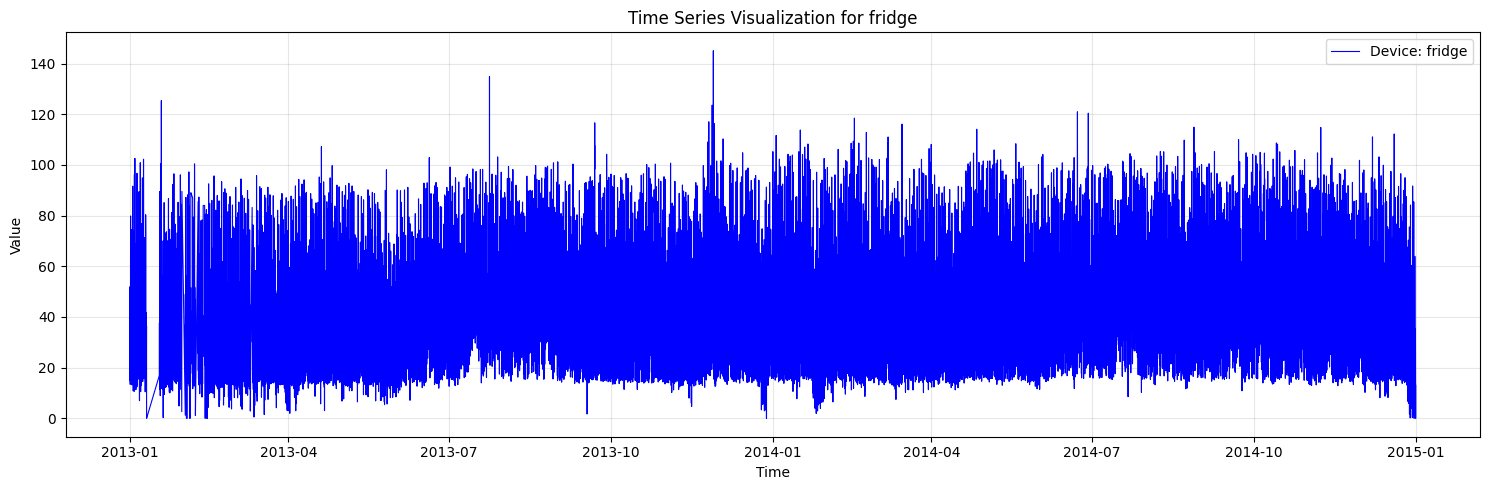

Number of rolling evaluation windows: 365
Data preprocessing completed


In [ ]:
df_train_base = df[df['Year'] == 2013]
df_rolling = df[df['Year'] == 2014]

full_values = np.concatenate([df_train_base[CONFIG["target_col"]].values, df_rolling[CONFIG["target_col"]].values])
full_times = np.concatenate([df_train_base[CONFIG["time_col"]].values, df_rolling[CONFIG["time_col"]].values])

plt.figure(figsize=(15, 5))
plt.plot(full_times, full_values, label=f"Device: {DEVICE_TARGET}", color='blue', linewidth=0.8)
plt.title(f"Time Series Visualization for {DEVICE_TARGET}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Indices Rolling
train_size = len(df_train_base)
indices = range(train_size, len(full_values) - CONFIG["forecast_horizon"] + 1, CONFIG["stride"])
print(f"Number of rolling evaluation windows: {len(indices)}")



def update_master_checkpoint(date_key, model_name, predictions, rmse):
    master = {}
    if os.path.exists(MASTER_CHECKPOINT):
        with open(MASTER_CHECKPOINT, "rb") as f:
            master = pickle.load(f)

    master.setdefault(str(date_key), {})[model_name] = {
        "pred": predictions,
        "rmse": rmse
    }

    with open(MASTER_CHECKPOINT, "wb") as f:
        pickle.dump(master, f)

print("Data preprocessing completed")

In [ ]:
print(df.isna().sum())


datetime    0
power       0
Year        0
dtype: int64


## Stage 7 - Single ARIMA baseline

This stage runs rolling forecasts for the standalone ARIMA model. For each window, it grid-searches `(p, d, q)`, selects the best order by AIC/BIC/MML, refits each unique selected order, forecasts 24 hours ahead, and saves RMSE/MAPE/predictions to the master checkpoint.


In [ ]:
import os, pickle
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
import traceback

CHECKPOINT_DIR = CONFIG["checkpoint_dir"]
MASTER_PATH = os.path.join(CHECKPOINT_DIR, "master_results.pkl")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if os.path.exists(MASTER_PATH):
    with open(MASTER_PATH, "rb") as f:
        master_data = pickle.load(f)
else:
    master_data = {}

# Search space
P_RANGE = range(0, 3)     # 0..2
Q_RANGE = range(0, 3)     # 0..2
D_CANDIDATES = [0, 1]     # ARIMA only


def difference_series(x, d):
    x = np.asarray(x, dtype=float)
    if d == 0:
        return x.copy()
    for _ in range(d):
        x = np.diff(x)
    return x


def extract_arma_params_from_arima_result(model, p, q):
    param_dict = dict(zip(model.param_names, model.params))

    c = float(param_dict.get("const", 0.0))
    ar_params = np.array([param_dict.get(f"ar.L{i}", 0.0) for i in range(1, p + 1)], dtype=float)
    ma_params = np.array([param_dict.get(f"ma.L{i}", 0.0) for i in range(1, q + 1)], dtype=float)

    sigma2 = param_dict.get("sigma2", None)
    if sigma2 is None:
        sigma2 = getattr(model, "scale", np.nan)

    return c, ar_params, ma_params, float(sigma2)


pbar = tqdm(enumerate(indices), total=len(indices), desc="Single ARIMA (AIC/BIC/MML)")
for idx, start_test in pbar:
    current_date_ts = full_times[start_test]
    current_date = str(current_date_ts)
    pbar.set_description(f"Processing {current_date}")

    # 1) Resume / Skip
    required_keys = ["Single_ARIMA_AIC", "Single_ARIMA_BIC", "Single_ARIMA_MML"]
    if current_date in master_data:
        existing = master_data[current_date].keys()
        if all(k in existing for k in required_keys):
            continue

    # 2) Split train/test
    train_end = start_test
    train_start = max(0, train_end - train_size)
    train_data = full_values[train_start:train_end]
    test_data = full_values[start_test : start_test + CONFIG["forecast_horizon"]]

    if len(train_data) < 10 or len(test_data) == 0:
        continue

    # 3) Grid search: collect best for AIC, BIC, MML
    best = {
        "aic": {"order": None, "score": np.inf},
        "bic": {"order": None, "score": np.inf},
        "mml": {"order": None, "score": np.inf},
    }

    for p in P_RANGE:
        for q in Q_RANGE:
            for d in D_CANDIDATES:
                order = (p, d, q)
                try:
                    model = ARIMA(train_data, order=order).fit()

                    aic = float(model.aic)
                    bic = float(model.bic)

                    x_diff = difference_series(train_data, d)

                    if len(x_diff) <= max(p, q):
                        mml = float("inf")
                    else:
                        c, ar_params, ma_params, sigma2 = extract_arma_params_from_arima_result(model, p, q)

                        ll_obs, score_obs = arma_score_obs_analytic(
                            x=x_diff,
                            c=c,
                            ar_params=ar_params,
                            ma_params=ma_params,
                            sigma2=sigma2
                        )

                        mml = float(calculate_mml87_wallace(ll_obs, score_obs, p=p, q=q,d=d))

                    if aic < best["aic"]["score"]:
                        best["aic"] = {"order": order, "score": aic}
                    if bic < best["bic"]["score"]:
                        best["bic"] = {"order": order, "score": bic}
                    if mml < best["mml"]["score"]:
                        best["mml"] = {"order": order, "score": mml}

                except Exception as e:
                    print(f"[GRID FAIL] order={order} | type={type(e).__name__} | msg={e}")
                    traceback.print_exc()
                    continue

    # nếu không tìm được model nào
    if best["aic"]["order"] is None and best["bic"]["order"] is None and best["mml"]["order"] is None:
        continue

    # 4) Build tasks & deduplicate orders (fit/predict 1 lần nếu trùng)
    tasks = [
        ("Single_ARIMA_AIC", best["aic"]["order"], best["aic"]["score"], "score"),
        ("Single_ARIMA_BIC", best["bic"]["order"], best["bic"]["score"], "score"),
        ("Single_ARIMA_MML", best["mml"]["order"], best["mml"]["score"], "mml_score"),
    ]

    unique_orders = {}
    for key, order, crit_score, score_field in tasks:
        if order is None:
            continue
        if order not in unique_orders:
            unique_orders[order] = []
        unique_orders[order].append({"key": key, "crit_score": crit_score, "score_field": score_field})

    if current_date not in master_data:
        master_data[current_date] = {}

    # 5) Refit & Forecast once per unique order
    for order, key_list in unique_orders.items():
        try:
            model = ARIMA(train_data, order=order).fit()
            pred = model.forecast(steps=len(test_data))
            rmse = float(np.sqrt(mean_squared_error(test_data, pred)))
            denom = np.maximum(np.abs(test_data), 1e-8)
            mape = float(np.mean(np.abs((test_data - pred) / denom)) * 100.0)

            for item in key_list:
                k = item["key"]
                master_data[current_date][k] = {
                    "rmse": rmse,
                    "mape": mape,
                    "pred": pred,
                    "order": order,
                    item["score_field"]: float(item["crit_score"]),
                }

                short = k.replace("Single_ARIMA_", "")
                print(
                    f"{current_date} | {short}: order={order} | "
                    f"{item['score_field']}={item['crit_score']:.2f} | RMSE={rmse:.4f}, MAPE ={mape:.4f}"
                )

        except Exception as e:
            print(f"Error fitting order {order} @ {current_date}: {e}")

    # 6) Save checkpoint
    with open(MASTER_PATH, "wb") as f:
        pickle.dump(master_data, f)

print("DONE: Single ARIMA AIC/BIC/MML")

Single ARIMA (AIC/BIC/MML):   0%|          | 0/365 [00:00<?, ?it/s]

DONE: Single ARIMA AIC/BIC/MML


In [ ]:
print("len(indices) =", len(indices))

len(indices) = 365


## Stage 8 - Hybrid ARIMA-LSTM

This stage takes the ARIMA order selected in the Single ARIMA stage, refits ARIMA to produce the linear forecast, trains an LSTM on training residuals, forecasts residuals recursively, and adds both components to produce the hybrid forecast.


In [ ]:
import os, pickle
import numpy as np
from sklearn.metrics import mean_squared_error
import gc
import random
import tensorflow as tf
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = "0"

# ============================================================
# 1) Rolling Hybrid Forecast: ARIMA + LSTM (NO LEAKAGE)
# ============================================================
def predict_hybrid_arima_lstm_rolling(
    arima_model,
    lstm_model,
    scaler,
    test_data,
    train_data_original,
    train_residuals,
    look_back=12,
    batch_size=None,
    max_window=5000
):
    steps_ahead = len(test_data)
    # (A) ARIMA linear forecast (one-shot)
    lin_pred = np.asarray(arima_model.forecast(steps=int(steps_ahead)), dtype=float)

    # (B) Seed residual window from TRAIN residuals (last look_back)
    resid = np.asarray(train_residuals, dtype=float)
    resid = resid[np.isfinite(resid)]

    raw = resid[-look_back:].tolist()
    if len(raw) < look_back:
        resid_window = np.array([0.0] * (look_back - len(raw)) + raw, dtype=float)
    else:
        resid_window = np.array(raw, dtype=float)

    # (C) LSTM residual forecast (recursive)
    nn_pred = np.zeros(int(steps_ahead), dtype=float)
    for t in range(int(steps_ahead)):
        x = resid_window.reshape(-1, 1)                 # (look_back, 1)
        x_scaled = scaler.transform(x).T.reshape(1, 1, look_back)  # (1,1,look_back)

        pred_scaled = float(lstm_model.predict(x_scaled, verbose=0)[0, 0])
        if not np.isfinite(pred_scaled):
            pred_scaled = 0.0

        pred_resid = float(scaler.inverse_transform([[pred_scaled]])[0, 0])
        nn_pred[t] = pred_resid

        resid_window = np.append(resid_window[1:], pred_resid)

    # (D) Combine
    return lin_pred + nn_pred


# ============================================================
# 2) Hybrid runner: AIC + BIC + MML using orders from master_data
# ============================================================

CRITERIA_LIST = ["aic", "bic", "mml"]   # ✅ thêm MML

FINAL_LSTM_PARAMS = {"lookback": 24, "units": 32}

CHECKPOINT_DIR = CONFIG["checkpoint_dir"]
MASTER_PATH = os.path.join(CHECKPOINT_DIR, "master_results.pkl")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if os.path.exists(MASTER_PATH):
    with open(MASTER_PATH, "rb") as f:
        master_data = pickle.load(f)
    print(f"[FOUND] MASTER: {MASTER_PATH}")
else:
    master_data = {}
    print(f"[NEW] MASTER: {MASTER_PATH}")


pbar = tqdm(enumerate(indices), total=len(indices), desc="Hybrid ARIMA-LSTM (AIC/BIC/MML)")
for idx, start_test in pbar:
    current_date = str(full_times[start_test])
    pbar.set_description(f"Hybrid {current_date}")

    train_end = start_test
    train_start = max(0, train_end - train_size)
    train_data = full_values[train_start:train_end]
    test_data = full_values[start_test : start_test + CONFIG["forecast_horizon"]]

    if len(train_data) < 50 or len(test_data) == 0:
        continue

    if current_date not in master_data:
        master_data[current_date] = {}
    # ================================
    # RUN HYBRID ONCE PER UNIQUE ORDER
    # ================================

    # 1) Lấy order cho từng criterion
    crit_to_order = {}
    for crit in CRITERIA_LIST:
        crit_upper = crit.upper()
        source_key = f"Single_ARIMA_{crit_upper}"

        if source_key not in master_data[current_date]:
            tqdm.write(f"{current_date} | SKIP Missing source: {source_key}")
            continue

        order_tuple = master_data[current_date][source_key].get("order", None)
        if order_tuple is None:
            tqdm.write(f"{current_date} | SKIP Source has no order: {source_key}")
            continue

        crit_to_order[crit] = tuple(order_tuple)

    # 2) Group các criterion theo order
    order_to_crits = {}
    for crit, order in crit_to_order.items():
        order_to_crits.setdefault(order, []).append(crit)

    # 3) Với mỗi order unique: fit ARIMA + train LSTM + forecast đúng 1 lần
    for order_tuple, crits in order_to_crits.items():

        # nếu tất cả crit trong nhóm đã có kết quả thì skip
        if all(f"Hybrid_ARIMA_LSTM_{c.upper()}" in master_data[current_date] for c in crits):
            continue

        try:
            # (a) Fit ARIMA 1 lần
            m_arima = ARIMA(train_data, order=order_tuple).fit()

            # (b) Residuals 1 lần
            fitted = np.asarray(m_arima.fittedvalues, dtype=np.float64)
            y_aligned = np.asarray(train_data[-len(fitted):], dtype=np.float64)
            resid = y_aligned - fitted
            resid = resid[np.isfinite(resid)]

            # (c) Train LSTM 1 lần
            lb = int(FINAL_LSTM_PARAMS["lookback"])
            units = int(FINAL_LSTM_PARAMS["units"])

            tf.keras.backend.clear_session()
            gc.collect()
            random.seed(0)
            np.random.seed(0)
            tf.random.set_seed(0)

            lstm_model, scaler_l, history = train_lstm_residual_no_es(
                resid,
                look_back=lb,
                epochs=300,
                batch_size=64,
                units=units
            )

            # (d) Forecast 1 lần
            pred = predict_hybrid_arima_lstm_rolling(
                arima_model=m_arima,
                lstm_model=lstm_model,
                scaler=scaler_l,
                test_data=test_data,
                train_data_original=train_data,
                train_residuals=resid,
                look_back=lb,
                batch_size=len(test_data)
            )

            rmse = float(np.sqrt(mean_squared_error(test_data, pred)))

            # output chung cho nhóm order này
            base_out = {
                "rmse": rmse,
                "pred": pred,
                "order": order_tuple,
                "lstm_params": {"lookback": lb, "units": units},
            }

            # (e) Ghi kết quả cho từng criterion cùng order
            for crit in crits:
                model_name = f"Hybrid_ARIMA_LSTM_{crit.upper()}"
                if model_name in master_data[current_date]:
                    continue

                out = dict(base_out)  # copy

                src = master_data[current_date][f"Single_ARIMA_{crit.upper()}"]
                crit_score = src.get("score", None)
                mml_score = src.get("mml_score", None)

                if crit in ("aic", "bic") and crit_score is not None:
                    out["linear_score"] = float(crit_score)
                if crit == "mml" and mml_score is not None:
                    out["linear_mml_score"] = float(mml_score)

                master_data[current_date][model_name] = out
                print(f"{current_date} | {model_name}: order={order_tuple} | RMSE={rmse:.4f}")

        except Exception as e:
            for crit in crits:
                model_name = f"Hybrid_ARIMA_LSTM_{crit.upper()}"
                print(f"{current_date} | {model_name} ERROR (shared order={order_tuple}): {e}")



    # Save checkpoint after each rolling origin
    with open(MASTER_PATH, "wb") as f:
        pickle.dump(master_data, f)

print("DONE Hybrid ARIMA-LSTM (AIC/BIC/MML)")


[FOUND] MASTER: /content/drive/MyDrive/Codepower2/fridge/master_results.pkl


Hybrid ARIMA-LSTM (AIC/BIC/MML):   0%|          | 0/365 [00:00<?, ?it/s]

DONE Hybrid ARIMA-LSTM (AIC/BIC/MML)


## Stage 9 - Single ARFIMA preparation

The next cells prepare and run the standalone ARFIMA experiment. The first two cells in this stage are already commented out and can be used for checkpoint maintenance if needed; the following cells define MLE/MML helpers and run the rolling forecast.


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# import pickle

# path = "/content/drive/MyDrive/Codepower/fridge/master_results.pkl"

# with open(path, "rb") as f:
#     data = pickle.load(f)


In [ ]:
# # Xoá các key liên quan Single_ARFIMA
# for date in list(data.keys()):
#     sub = data[date]

#     keys_to_delete = [k for k in sub if "Single_ARFIMA" in k]

#     for k in keys_to_delete:
#         del sub[k]

#     # nếu ngày đó không còn dữ liệu thì xoá luôn
#     if len(sub) == 0:
#         del data[date]

### Stage 9.1 - ARFIMA MLE and MML helper functions

These functions optimize the continuous `d` parameter, fit ARMA on the fractionally differenced series, align pointwise log-likelihood values around `d`, and build the score/Fisher matrix required for ARFIMA MML scoring.


In [ ]:
import numpy as np
from scipy.optimize import minimize
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------------------------
# Fit ARMA on fractionally differenced series at a given d
# Return fitted result, effective nobs, and pointwise loglik
# ------------------------------------------------------------
def fit_arma_on_fracdiff(train_data, d, p, q, thres=1e-5):
    diff_train = utils.fractional_diff(train_data, float(d), thres=thres)
    diff_train = np.asarray(diff_train, dtype=float)
    diff_train = diff_train[~np.isnan(diff_train)]

    if diff_train.size < 50:
        raise ValueError("Too few observations after fractional diff.")

    res = ARIMA(diff_train, order=(int(p), 0, int(q))).fit()

    # Pointwise log-likelihood contributions
    ll_obs = np.asarray(res.model.loglikeobs(res.params), dtype=float)
    ll_obs = ll_obs[np.isfinite(ll_obs)]

    if ll_obs.size < 10:
        raise ValueError("Too few valid pointwise log-likelihood values.")

    return res, ll_obs.size, ll_obs


# ------------------------------------------------------------
# Profile negative log-likelihood as a function of d
# ------------------------------------------------------------
def profile_neg_ll(d_array, train_data, p, q, thres=1e-5):
    d = float(d_array[0])
    try:
        _, _, ll_obs = fit_arma_on_fracdiff(train_data, d, p, q, thres=thres)
        return -float(np.sum(ll_obs))
    except Exception:
        return np.inf


# ------------------------------------------------------------
# Optimize d by MLE
# ------------------------------------------------------------
def mle_optimize_d(train_data, p, q, d_bounds=(-0.49, 0.49), d0=0.1, thres=1e-5):
    out = minimize(
        profile_neg_ll,
        x0=np.array([d0], dtype=float),
        args=(train_data, p, q, thres),
        method="L-BFGS-B",
        bounds=[d_bounds],
        options={"maxiter": 20, "ftol": 1e-4},
    )
    if (not out.success) or (not np.isfinite(out.fun)):
        raise ValueError(f"MLE optimize d failed: {out.message}")
    return float(out.x[0]), float(out.fun)


# ------------------------------------------------------------
# Build pointwise log-likelihood vectors at d-h, d, d+h
# and align them to same length
# ------------------------------------------------------------
def get_aligned_ll_obs_triplet(train_data, d, h, p, q, thres=1e-5):
    _, _, ll_m = fit_arma_on_fracdiff(train_data, d - h, p, q, thres=thres)
    res_0, _, ll_0 = fit_arma_on_fracdiff(train_data, d, p, q, thres=thres)
    _, _, ll_p = fit_arma_on_fracdiff(train_data, d + h, p, q, thres=thres)

    n_common = min(len(ll_m), len(ll_0), len(ll_p))
    if n_common < 10:
        raise ValueError("Too few aligned pointwise log-likelihood values.")

    ll_m = np.asarray(ll_m[-n_common:], dtype=float)
    ll_0 = np.asarray(ll_0[-n_common:], dtype=float)
    ll_p = np.asarray(ll_p[-n_common:], dtype=float)

    return res_0, n_common, ll_m, ll_0, ll_p

In [ ]:
import numpy as np

def empirical_fisher_full_from_scores(score_obs_full, ridge=1e-10):
    score_obs_full = np.asarray(score_obs_full, dtype=float)

    if score_obs_full.ndim != 2 or score_obs_full.shape[0] == 0:
        raise ValueError("Invalid full score matrix.")

    # Wallace-style empirical Fisher
    I_emp = (score_obs_full.T @ score_obs_full) / float(score_obs_full.shape[0])

    # Symmetrize
    I_emp = 0.5 * (I_emp + I_emp.T)

    # Small ridge for stability
    I_emp = I_emp + ridge * np.eye(I_emp.shape[0])

    eigvals = np.linalg.eigvalsh(I_emp)
    if np.any(~np.isfinite(eigvals)) or np.any(eigvals <= 0):
        raise ValueError("Full empirical Fisher matrix is not positive definite.")

    return I_emp


def calculate_mml87_wallace_arfima(
    score_obs_arma,
    ll_obs_dm,
    ll_obs_d,
    ll_obs_dp,
    h,
    p,
    q,
    include_structural_pq=True,
    ridge=1e-10
):
    # Negative log-likelihood at optimum
    neg_ll = -float(np.sum(ll_obs_d))

    # Ensure arrays
    score_obs_arma = np.asarray(score_obs_arma, dtype=float)
    ll_obs_dm = np.asarray(ll_obs_dm, dtype=float)
    ll_obs_d  = np.asarray(ll_obs_d, dtype=float)
    ll_obs_dp = np.asarray(ll_obs_dp, dtype=float)

    # Align all to same effective length
    n_common = min(score_obs_arma.shape[0], ll_obs_dm.size, ll_obs_d.size, ll_obs_dp.size)
    if n_common < 10:
        return float("inf")

    score_obs_arma = score_obs_arma[-n_common:, :]
    ll_obs_dm = ll_obs_dm[-n_common:]
    ll_obs_d  = ll_obs_d[-n_common:]
    ll_obs_dp = ll_obs_dp[-n_common:]

    # Numerical score for d
    score_d_obs = (ll_obs_dp - ll_obs_dm) / (2.0 * h)
    score_d_obs = score_d_obs.reshape(-1, 1)

    # Full score matrix: [beta scores | d score]
    score_obs_full = np.hstack([score_obs_arma, score_d_obs])

    # Full Fisher matrix
    I_full = empirical_fisher_full_from_scores(score_obs_full, ridge=ridge)

    eigvals = np.linalg.eigvalsh(I_full)
    fisher = 0.5 * np.sum(np.log(eigvals))

    # Total number of continuous parameters
    k_full = I_full.shape[0]

    if k_full == 1:
        kappa = 1 / 12
    elif k_full == 2:
        kappa = 5 / (36 * np.sqrt(3))
    elif k_full == 3:
        kappa = 19 / (192 * (2 ** (1 / 3)))
    else:
        kappa = 1 / (2 * np.pi * np.e)

    lattice = 0.5 * k_full * (1.0 + np.log(kappa))

    pq_prior = 0.0
    if include_structural_pq:
        pq_prior = (2 + int(p) + int(q)) * np.log(2.0)

    return float(neg_ll + fisher + lattice + pq_prior)

### Stage 9.2 - Single ARFIMA rolling experiment

For each rolling window, this stage grid-searches `(p, q)`, optimizes `d`, selects the best configuration by AIC/BIC/MML, forecasts back in level space, and saves the results to the master checkpoint.


In [ ]:
import os, pickle, itertools
import tensorflow as tf
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = "0"
# =========================
# CHECKPOINT
# =========================
CHECKPOINT_DIR = CONFIG["checkpoint_dir"]
MASTER_PATH = os.path.join(CHECKPOINT_DIR, "master_results.pkl")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if os.path.exists(MASTER_PATH):
    with open(MASTER_PATH, "rb") as f:
        master_data = pickle.load(f)
else:
    master_data = {}


P_RANGE = [0, 1, 2]
Q_RANGE = [0, 1, 2]
PQ_PARAMS = list(itertools.product(P_RANGE, Q_RANGE))



pbar = tqdm(enumerate(indices), total=len(indices), desc="Single ARFIMA (AIC/BIC/MML)")

for idx, start_test in pbar:
    current_date = str(full_times[start_test])
    pbar.set_description(f"Processing {current_date}")

    # 1) Resume / Skip
    required_keys = ["Single_ARFIMA_AIC_", "Single_ARFIMA_BIC_", "Single_ARFIMA_MML_"]
    if current_date in master_data and all(k in master_data[current_date] for k in required_keys):
        continue

    # 2) Split train/test (rolling window)
    train_end = start_test
    train_start = max(0, train_end - train_size)
    train_data = np.asarray(full_values[train_start:train_end], dtype=float)
    test_data  = np.asarray(full_values[start_test : start_test + CONFIG["forecast_horizon"]], dtype=float)

    if len(train_data) < 50 or len(test_data) == 0:
        continue

    # 3) Grid search: best AIC/BIC/MML (scoring on diff-space model)
    # 3) Search best AIC/BIC/MML with continuous-d MLE for each (p,q)
    best = {
        "aic": {"order": None, "score": np.inf},
        "bic": {"order": None, "score": np.inf},
        "mml": {"order": None, "score": np.inf},
    }

    for (p, q) in PQ_PARAMS:
        if p == 0 and q == 0:
            continue

        try:
            # --- 3.1 optimize d (continuous MLE) ---
            d_hat, _ = mle_optimize_d(
                train_data=train_data,
                p=p, q=q,
                d_bounds=(-0.49, 0.49),
                d0=0.1,
                thres=1e-5
            )

            model, n_eff, ll_obs = fit_arma_on_fracdiff(train_data, d_hat, p, q, thres=1e-5)
            ll = float(np.sum(ll_obs))

            # IMPORTANT: AIC/BIC should count d as a parameter too (k_full = k_arma + 1)
            k_arma = int(len(model.params))
            k_full = k_arma + 1
            aic = float(-2.0 * ll + 2.0 * k_full)
            bic = float(-2.0 * ll + k_full * np.log(float(n_eff)))

            # --- 3.3 compute MML with joint Fisher ---
            d_lo, d_hi = -0.49, 0.49
            h = 1e-3
            dp = min(d_hat + h, d_hi - 1e-6)
            dm = max(d_hat - h, d_lo + 1e-6)

            # build aligned ll vectors at d-h, d, d+h
            _, n_common, ll_obs_m, ll_obs_0, ll_obs_p = get_aligned_ll_obs_triplet(
                train_data=train_data,
                d=d_hat,
                h=h,
                p=p,
                q=q,
                thres=1e-5
            )

            # fractionally differenced series at d_hat
            diff_train = utils.fractional_diff(train_data, float(d_hat), thres=1e-5)
            diff_train = np.asarray(diff_train, dtype=float)
            diff_train = diff_train[~np.isnan(diff_train)]

            # extract fitted ARMA params from model
            params = model.params
            param_names = list(model.param_names)

            c = 0.0
            ar_params = []
            ma_params = []
            sigma2 = None

            for name, val in zip(param_names, params):
                lname = name.lower()
                if lname in ["const", "intercept"]:
                    c = float(val)
                elif "ar." in lname or lname.startswith("ar.l"):
                    ar_params.append(float(val))
                elif "ma." in lname or lname.startswith("ma.l"):
                    ma_params.append(float(val))
                elif lname in ["sigma2", "sigma2.irregular"]:
                    sigma2 = float(val)

            ar_params = np.asarray(ar_params, dtype=float)
            ma_params = np.asarray(ma_params, dtype=float)

            if sigma2 is None or sigma2 <= 0:
                raise ValueError("Invalid sigma2")

            # analytic score for beta = (AR, MA, sigma2, maybe const if your function includes it)
            _, score_obs_arma = arma_score_obs_analytic(
                x=diff_train,
                c=c,
                ar_params=ar_params,
                ma_params=ma_params,
                sigma2=sigma2
            )

            mml = float(
                calculate_mml87_wallace_arfima(
                    score_obs_arma=score_obs_arma,
                    ll_obs_dm=ll_obs_m,
                    ll_obs_d=ll_obs_0,
                    ll_obs_dp=ll_obs_p,
                    h=h,
                    p=p,
                    q=q,
                    include_structural_pq=True
                )
            )
            order = (int(p), float(d_hat), int(q))

            if aic < best["aic"]["score"]:
                best["aic"] = {"order": order, "score": aic}
            if bic < best["bic"]["score"]:
                best["bic"] = {"order": order, "score": bic}
            if mml < best["mml"]["score"]:
                best["mml"] = {"order": order, "score": mml}

        except Exception as e:
          continue
    if all(best[c]["order"] is None for c in ["aic", "bic", "mml"]):
        continue

    # 4) Deduplicate orders (forecast 1 lần nếu trùng)
    tasks = [
        ("Single_ARFIMA_AIC_", best["aic"]["order"], best["aic"]["score"], "score"),
        ("Single_ARFIMA_BIC_", best["bic"]["order"], best["bic"]["score"], "score"),
        ("Single_ARFIMA_MML_", best["mml"]["order"], best["mml"]["score"], "mml_score"),
    ]

    unique_orders = {}
    for key, order, crit_score, score_field in tasks:
        if order is None:
            continue
        unique_orders.setdefault(order, []).append(
            {"key": key, "crit_score": float(crit_score), "score_field": score_field}
        )

    master_data.setdefault(current_date, {})

    # 5) Forecast LEVEL by arfima_fit_predict_level + RMSE on LEVEL
    for (p, d, q), key_list in unique_orders.items():
        try:
            _, _, yhat_future, _ = arfima_fit_predict_level(
                y_train=train_data,
                steps_ahead=len(test_data),
                p=int(p), d=float(d), q=int(q),
                thres=1e-5
            )

            pred = np.asarray(yhat_future, dtype=float)

            if pred.size != len(test_data):
                raise ValueError(f"forecast length {pred.size} != horizon {len(test_data)}")

            rmse = float(np.sqrt(mean_squared_error(test_data, pred)))   # ✅ level-space RMSE

            for item in key_list:
                k = item["key"]
                master_data[current_date][k] = {
                    "rmse": rmse,
                    "pred": pred,
                    "order": {"arma": (int(p), 0, int(q)), "d": float(d), "full": (int(p), float(d), int(q))},
                    item["score_field"]: float(item["crit_score"]),
                }

        except Exception as e:
            print(f"Error forecasting {(p,d,q)} @ {current_date}: {e}")

    # 6) Save checkpoint
    with open(MASTER_PATH, "wb") as f:
        pickle.dump(master_data, f)

print("DONE: Single ARFIMA (AIC/BIC/MML) with LEVEL-space RMSE")


Single ARFIMA (AIC/BIC/MML):   0%|          | 0/365 [00:00<?, ?it/s]

DONE: Single ARFIMA (AIC/BIC/MML) with LEVEL-space RMSE


## Stage 10 - Hybrid ARFIMA-LSTM

The final modelling stage reads the best ARFIMA orders from the master checkpoint, refits ARFIMA to obtain the linear forecast and residuals, trains an LSTM on the residual series, adds both forecast components, and saves results for AIC/BIC/MML.


In [ ]:
import os, pickle
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm

import random
import tensorflow as tf
import gc
tf.config.experimental.enable_op_determinism()
os.environ["PYTHONHASHSEED"] = "0"


CRITERIA_LIST = ["aic", "bic", "mml"]

FINAL_LSTM_PARAMS = {"lookback": 24, "units": 32}


CHECKPOINT_DIR = CONFIG["checkpoint_dir"]
MASTER_PATH = os.path.join(CHECKPOINT_DIR, "master_results.pkl")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

if os.path.exists(MASTER_PATH):
    with open(MASTER_PATH, "rb") as f:
        master_data = pickle.load(f)
    print(f"[FOUND] MASTER: {MASTER_PATH}")
else:
    master_data = {}
    print(f"[NEW] MASTER: {MASTER_PATH}")


# ============================================================
# Hybrid rolling forecast: ARFIMA (level) + LSTM residual
# ============================================================
def predict_hybrid_arfima_lstm_rolling(
    lstm_model, scaler,
    test_data, train_data_original, train_residuals,
    order_full, look_back=12, batch_size=None,
    thres=1e-5
):
    steps_ahead = len(test_data)
    if steps_ahead <= 0:
        return np.array([], dtype=float)

    p, d, q = order_full
    p, d, q = int(p), float(d), int(q)

    # ------------------------------------------------------------
    # (A) Linear forecast: ARFIMA level forecast
    # ------------------------------------------------------------
    try:
        _, _, yhat_future, _ = arfima_fit_predict_level(
            y_train=np.asarray(train_data_original, dtype=np.float64),
            steps_ahead=int(steps_ahead),
            p=p, d=d, q=q,
            thres=thres
        )
        lin_pred = np.asarray(yhat_future, dtype=float)

        if lin_pred.size != steps_ahead:
            raise ValueError(f"ARFIMA forecast length {lin_pred.size} != {steps_ahead}")

    except Exception:
        last_val = float(np.asarray(train_data_original, dtype=float)[-1])
        lin_pred = np.full(steps_ahead, last_val, dtype=float)

    # ------------------------------------------------------------
    # (B) Seed residual window from TRAIN residuals
    # ------------------------------------------------------------
    resid = np.asarray(train_residuals, dtype=float)
    resid = resid[np.isfinite(resid)]

    raw = resid[-look_back:].tolist()
    if len(raw) < look_back:
        resid_window = np.array([0.0] * (look_back - len(raw)) + raw, dtype=float)
    else:
        resid_window = np.array(raw, dtype=float)

    # ------------------------------------------------------------
    # (C) Residual forecast: LSTM recursive forecast
    # ------------------------------------------------------------
    nn_pred = np.zeros(steps_ahead, dtype=float)

    for t in range(steps_ahead):
        try:
            x = resid_window.reshape(-1, 1)
            x_scaled = scaler.transform(x).T.reshape(1, 1, look_back)

            pred_scaled = float(lstm_model.predict(x_scaled, verbose=0)[0, 0])
            if not np.isfinite(pred_scaled):
                pred_scaled = 0.0

            pred_resid = float(scaler.inverse_transform([[pred_scaled]])[0, 0])

        except Exception:
            pred_resid = 0.0

        nn_pred[t] = pred_resid
        resid_window = np.append(resid_window[1:], pred_resid)

    # ------------------------------------------------------------
    # (D) Combine
    # ------------------------------------------------------------
    return lin_pred + nn_pred


# =========================
# MAIN LOOP (DEDUP by order_full)
# =========================
pbar = tqdm(enumerate(indices), total=len(indices), desc="Hybrid ARFIMA-LSTM (AIC/BIC/MML)")

for idx, start_test in pbar:
    current_date = str(full_times[start_test])
    pbar.set_description(f"Hybrid {current_date}")

    train_end = start_test
    train_start = max(0, train_end - train_size)
    train_data = np.asarray(full_values[train_start:train_end], dtype=float)
    test_data  = np.asarray(full_values[start_test : start_test + CONFIG["forecast_horizon"]], dtype=float)

    if len(train_data) < 50 or len(test_data) == 0:
        continue

    master_data.setdefault(current_date, {})

    # ------------------------------------------------------------
    # A) Collect (crit -> order_full) and group criteria by order_full
    # ------------------------------------------------------------
    order_to_criteria = {}   # order_full -> [crit,...]
    source_for_crit = {}     # crit -> src dict

    for crit in CRITERIA_LIST:
        crit_upper = crit.upper()
        model_name = f"Hybrid_ARFIMA_LSTM_{crit_upper}"
        source_key = f"Single_ARFIMA_{crit_upper}_"

        # already computed
        if model_name in master_data[current_date]:
            continue

        # need baseline order
        if source_key not in master_data[current_date]:
            tqdm.write(f"{current_date} | SKIP Missing source: {source_key}")
            continue

        src = master_data[current_date][source_key]
        source_for_crit[crit] = src

        try:
            order_full = tuple(src["order"]["full"])
            p_best, d_best, q_best = int(order_full[0]), float(order_full[1]), int(order_full[2])
            order_full = (p_best, d_best, q_best)
        except Exception:
            tqdm.write(f"{current_date} | SKIP Bad order format in {source_key} (need order['full'])")
            continue

        order_to_criteria.setdefault(order_full, []).append(crit)

    # Nothing to do
    if len(order_to_criteria) == 0:
        continue

    # ------------------------------------------------------------
    # B) Run ONCE per unique order_full, then copy to all criteria
    # ------------------------------------------------------------
    for order_full, crit_list in order_to_criteria.items():
        # pick a runner (first criterion)
        runner_crit = crit_list[0]
        runner_upper = runner_crit.upper()
        runner_model_name = f"Hybrid_ARFIMA_LSTM_{runner_upper}"

        # if runner already exists (rare), reuse it
        if runner_model_name in master_data[current_date]:
            out_base = master_data[current_date][runner_model_name]
        else:
            p_best, d_best, q_best = int(order_full[0]), float(order_full[1]), int(order_full[2])

            try:
                # 1) residuals in LEVEL
                yhat_train, y_train_aligned, _, _ = arfima_fit_predict_level(
                    y_train=train_data,
                    steps_ahead=0,
                    p=p_best, d=d_best, q=q_best,
                    thres=1e-5
                )
                if yhat_train.size == 0 or y_train_aligned.size == 0:
                    raise ValueError("ARFIMA fitted empty (not enough valid diff points)")

                resid_ann = np.asarray(y_train_aligned - yhat_train, dtype=float)
                resid_ann = resid_ann[np.isfinite(resid_ann)]

                # 2) LSTM train (ONE TIME)
                lb = int(FINAL_LSTM_PARAMS["lookback"])
                units = int(FINAL_LSTM_PARAMS["units"])

                tf.keras.backend.clear_session()
                gc.collect()
                random.seed(0)
                np.random.seed(0)
                tf.random.set_seed(0)

                lstm_model, scaler_l, history = train_lstm_residual_no_es(
                    resid_ann,
                    look_back=lb,
                    epochs=300,
                    batch_size=64,
                    units=units
                )

                # 3) hybrid forecast (ONE TIME)
                pred = predict_hybrid_arfima_lstm_rolling(
                    lstm_model=lstm_model,
                    scaler=scaler_l,
                    test_data=test_data,
                    train_data_original=train_data,
                    train_residuals=resid_ann,
                    order_full=order_full,
                    look_back=lb,
                    batch_size=len(test_data),
                    thres=1e-5
                )

                rmse = float(np.sqrt(mean_squared_error(test_data, pred)))

                out_base = {
                    "rmse": rmse,
                    "pred": pred,
                    "order": {"full": order_full, "arma": (p_best, 0, q_best), "d": d_best},
                    "arfima_lstm_params": {"lookback": lb, "units": units},
                    "final_train_loss": float(history.history["loss"][-1]) if hasattr(history, "history") and "loss" in history.history else None,
                }

                # store runner
                master_data[current_date][runner_model_name] = out_base
                print(f"{current_date} | {runner_model_name}: order={order_full} | RMSE={rmse:.4f}")

            except Exception as e:
                print(f"{current_date} | {runner_model_name} ERROR: {e}")
                continue

        # --------------------------------------------------------
        # C) Copy SAME out_base to every criterion that picked it
        # --------------------------------------------------------
        for crit in crit_list:
            crit_upper = crit.upper()
            model_name = f"Hybrid_ARFIMA_LSTM_{crit_upper}"

            if model_name in master_data[current_date]:
                continue

            out_copy = dict(out_base)

            src = source_for_crit.get(crit, {})
            if crit in ("aic", "bic"):
                sc = src.get("score", None)
                if sc is not None:
                    out_copy["linear_score"] = float(sc)
            if crit == "mml":
                ms = src.get("mml_score", None)
                if ms is not None:
                    out_copy["linear_mml_score"] = float(ms)

            master_data[current_date][model_name] = out_copy

    # Save checkpoint each rolling origin
    with open(MASTER_PATH, "wb") as f:
        pickle.dump(master_data, f)

print("DONE Hybrid ARFIMA-LSTM (AIC/BIC/MML)")


[FOUND] MASTER: /content/drive/MyDrive/Codepower2/fridge/master_results.pkl


Hybrid ARFIMA-LSTM (AIC/BIC/MML):   0%|          | 0/365 [00:00<?, ?it/s]

2014-11-03T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.10000002989677143, 2) | RMSE=13.8856
2014-11-04T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.10000000162260948, 2) | RMSE=18.3509
2014-11-05T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(1, 0.49, 2) | RMSE=22.0023
2014-11-06T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.09830573929377955, 2) | RMSE=20.1159
2014-11-07T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.09993952201455336, 2) | RMSE=14.7194
2014-11-08T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.10000000000000103, 2) | RMSE=19.7861
2014-11-09T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.09999999998676463, 2) | RMSE=20.1677
2014-11-10T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.09999998707903963, 2) | RMSE=18.5504
2014-11-11T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.09998989355672905, 2) | RMSE=16.7891
2014-11-12T00:00:00.000000000 | Hybrid_ARFIMA_LSTM_AIC: order=(2, 0.08

## Stage 11 - Output results

After all stages finish, results are collected in `master_results.pkl` by rolling date and model name. This checkpoint file is used to compare RMSE/MAPE across Single ARIMA, Hybrid ARIMA-LSTM, Single ARFIMA, and Hybrid ARFIMA-LSTM.
